<img src="./logo_UNSAM.png" align="right" width="150" /> 

# Trabajo Semanal Nº1 

#### Nicolás Galván

## Ejercicio Nº1

### Función sinusoidal de 2 KHz

Llamo a las librerías a utilizar y defino mis variables que voy a implementar.

In [98]:
import numpy as np
import matplotlib.pyplot as plt

fm=100000 #frecuencia de muestreo
N=500     #cantidad de muestras
fs=2000   #frecuencia de la señal
dt=1/fm  #tiempo entre muestras

Defino mi función seno.

In [99]:
def mi_funcion_sen(vmax, dc, ff, ph, nn, fs):
    tt = np.arange(0, nn, 1) * (1/fs)
    xx = dc + vmax * np.sin(2*np.pi*ff*tt + ph)
    return tt, xx 

Se llama a la función pasándole como parámetros la amplitud máxima de la señal senoidal, el valor medio, la frecuencia, la fase, el número de muestras tomadas por el ADC y la frecuencia de muestreo del ADC.

In [100]:
tt, xx = mi_funcion_sen(vmax=1, dc=0, ff=fs, ph=0, nn=N, fs=fm)

In [101]:
muestras=len(xx)
tiempoMuestras= dt
print(f'La función senoidal es de potencia')
print(f'La cantidad de muestras es: {muestras}')
print(f'El tiempo entre muestras es: {tiempoMuestras}s')

La función senoidal es de potencia
La cantidad de muestras es: 500
El tiempo entre muestras es: 1e-05s


Se grafica la función a partir de los parámetros obtenidos anteriormente.

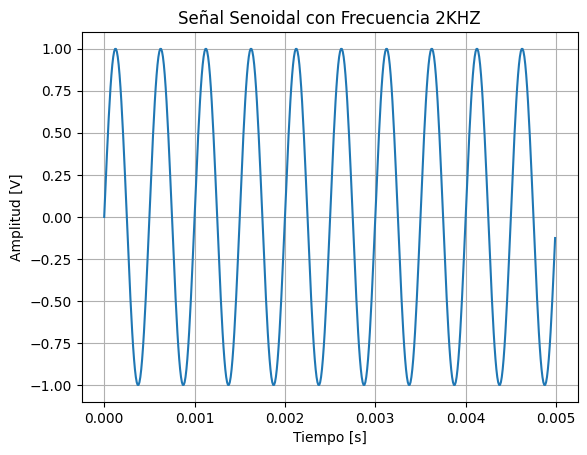

In [102]:
plt.figure(1)
plt.plot(tt, xx, label='{f} Hz')
plt.title('Señal Senoidal con Frecuencia 2KHZ')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [V]')
plt.grid(True)
plt.show()

### Función desfasada y amplificada

Se llama nuevamente a la función pasándole los nuevo parámetros de amplitud máxima de la señal senoidal y de fase.

In [103]:
tt1, xx1 = mi_funcion_sen(vmax=3, dc=0, ff=fs, ph=np.pi/2, nn=N, fs=fm)

In [104]:
muestras=len(xx1)
tiempoMuestras= dt
print(f'La función senoidal es de potencia')
print(f'La cantidad de muestras es: {muestras}')
print(f'El tiempo entre muestras es: {tiempoMuestras}s')

La función senoidal es de potencia
La cantidad de muestras es: 500
El tiempo entre muestras es: 1e-05s


Se grafica la función a partir de los parámetros nuevos. 

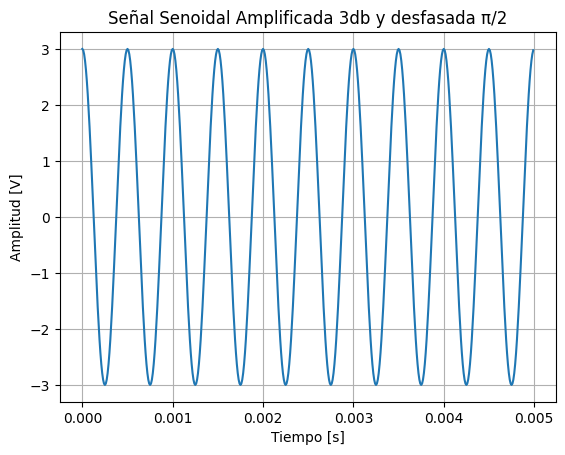

In [105]:
plt.figure(2)
plt.plot(tt1, xx1, label='{f} Hz')
plt.title('Señal Senoidal Amplificada 3db y desfasada π/2')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [V]')
plt.grid(True)
plt.show()

### Señal modulada en amplitud por otra señal sinusoidal de frecuencia de 1000 KHz

Defino mi función modulante. 

In [106]:
def mi_funcion_sen_modulante(vmax, dc, ff, ph, nn, fs):
    tt = np.arange(0, nn, 1) * (1/fs)
    xx = dc + vmax * np.sin(2*np.pi*ff*tt + ph)
    return tt, xx 

Se llama a la función pasándole el parámetro de frecuencia.

In [107]:
fs2 = 1000
tt2, xx2 = mi_funcion_sen_modulante(vmax=1, dc=0, ff=fs2, ph=0, nn=N, fs=fm)

Genero mi funcion modulada.

In [108]:
modulada = xx2 * xx

In [109]:
muestras=len(xx2)
tiempoMuestras= dt
print(f'La función senoidal es de potencia')
print(f'La cantidad de muestras es: {muestras}')
print(f'El tiempo entre muestras es: {tiempoMuestras}s')

La función senoidal es de potencia
La cantidad de muestras es: 500
El tiempo entre muestras es: 1e-05s


Se grafica la función modulada.

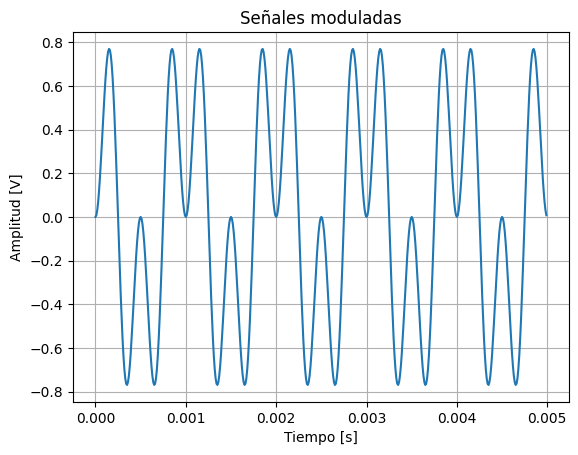

In [110]:
plt.figure(3)
plt.plot(tt, modulada)
plt.title('Señales moduladas')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [V]')
plt.grid(True)
plt.show()

### Señal con efecto de saturación al 75% de su amplitud

Calculo la potencia y busco el 75% de esta.

In [111]:
vc=1
potencia=(vc**2)/2
threshold=potencia*0.75

Saturo los valores de xx al 75%. 

In [112]:
xxRecortada=np.clip(modulada,-threshold,threshold)

In [113]:
dt = 1/fm
muestras=len(xxRecortada)
tiempoMuestras= dt
print(f'La función senoidal es de potencia')
print(f'La cantidad de muestras es: {muestras}')
print(f'El tiempo entre muestras es: {tiempoMuestras}s')

La función senoidal es de potencia
La cantidad de muestras es: 500
El tiempo entre muestras es: 1e-05s


Se grafica la función con efecto de saturación al 75% de su amplitud.

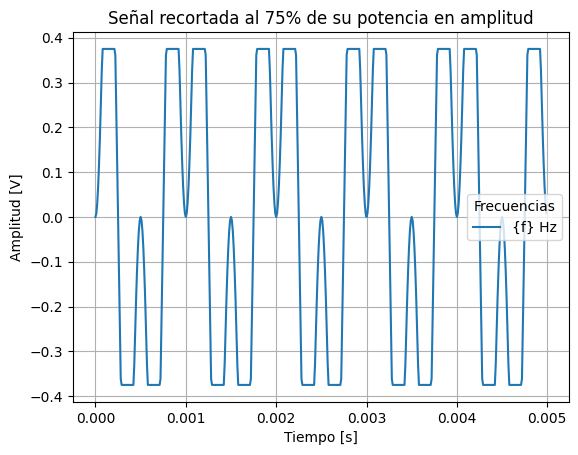

In [114]:
plt.figure(5)
plt.plot(tt, xxRecortada, label='{f} Hz')
plt.title('Señal recortada al 75% de su potencia en amplitud')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [V]')
plt.legend(title="Frecuencias")
plt.grid(True)
plt.show()

### Señal cuadrada de 4KHz.

Llamo una nueva librería a utilizar para hacer la señal cuadrada.

In [115]:
from scipy import signal

Defino mis variables a usar.

In [116]:
fs = 4000        # frecuencia de la señal (Hz)
T = 1/fs         # período (s)
fm = 100000      # frecuencia de muestreo (Hz)
t = np.linspace(0, N/fm, N, endpoint=False)

Genero mi función cuadrada.

In [117]:
señalcuadrada = signal.square(2 * np.pi * fs * t)

In [118]:
dt = 1/fm
muestras=len(señalcuadrada)
tiempoMuestras= dt
print(f'La función es de potencia')
print(f'La cantidad de muestras es: {muestras}')
print(f'El tiempo entre muestras es: {tiempoMuestras}s')


La función es de potencia
La cantidad de muestras es: 500
El tiempo entre muestras es: 1e-05s


Se grafica la función cuadrada de 4KHz.

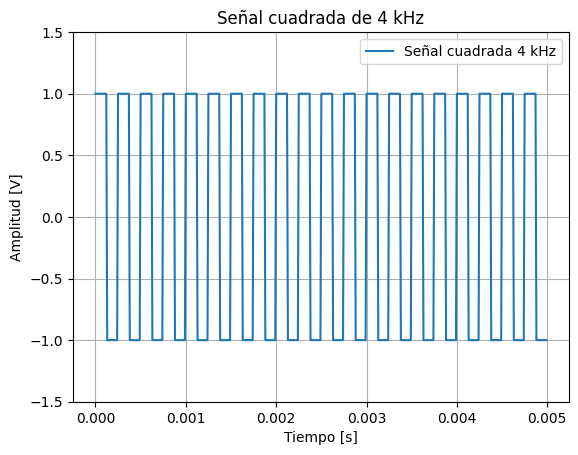

In [119]:
plt.figure(6)
plt.plot(t, señalcuadrada, label="Señal cuadrada 4 kHz")
plt.title("Señal cuadrada de 4 kHz")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.grid(True)
plt.ylim(-1.5, 1.5)
plt.legend()
plt.show()

### Un pulso rectangular de 10ms

Defino mis variables a usar.

In [120]:
fm = 100000        # frecuencia de muestreo [Hz]
T = 0.02           # tiempo total de simulación [s]
A = 1.0            # amplitud del pulso
t0 = 0             # inicio del pulso [s]
Tp = 10e-3         # duración del pulso [s]

Defino mi vector de tiempo.

In [121]:
t = np.arange(0, T, 1/fm)

Defino el pulso.

In [122]:
pulso = np.zeros_like(t)                   # todo en cero
pulso[(t >= t0) & (t < t0 + Tp)] = A       # intervalo activo

In [123]:
dt = 1/fm
muestras=len(pulso)
tiempoMuestras= dt
print(f'La función es de energia')
print(f'La cantidad de muestras es: {muestras}')
print(f'El tiempo entre muestras es: {tiempoMuestras}s')

La función es de energia
La cantidad de muestras es: 2000
El tiempo entre muestras es: 1e-05s


Se grafica el pulso rectangular de 10ms.

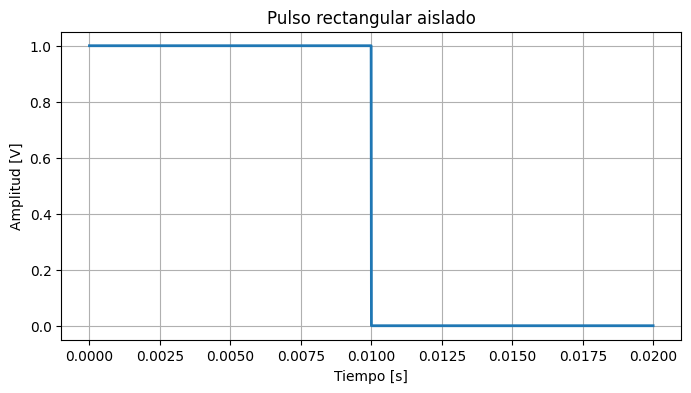

In [124]:
plt.figure(figsize=(8,4))
plt.plot(t, pulso, lw=2)
plt.title("Pulso rectangular aislado")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.grid(True)
plt.show()

## Ejercicio Nº2

In [125]:
from IPython.display import IFrame

IFrame("TS1_eje2.pdf", width=600, height=400)

### Verificación con Spyder

#### Caso a

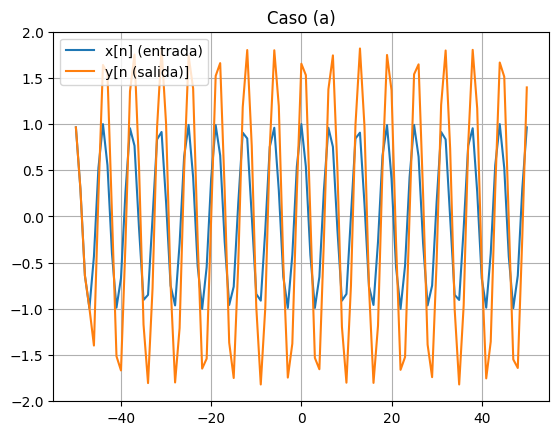

In [126]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as sig

# Eje centrado
n = np.arange(-50, 51)

# h[n] = δ[n] - δ[n-4]
h = np.zeros_like(n, dtype=float)
h[n == 0] = 1
h[n == 4] = -1

w0 = 1 # Uso este valor como ejemplo
Ts = 1 # Uso este valor como ejemplo

x_a = np.cos(w0 * n * Ts)
y_a = sig.convolve(x_a, h, mode='same')

plt.figure()
plt.title("Caso (a)")
plt.plot(n, x_a, label="x[n] (entrada)")
plt.plot(n, y_a, label="y[n (salida)]")
plt.legend()
plt.grid()

#### Caso b

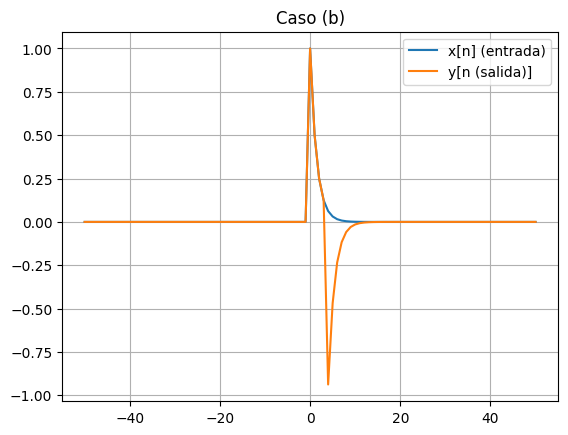

In [127]:
u = (n >= 0).astype(float)
x_b = (0.5 ** n) * u
y_b = sig.convolve(x_b, h, mode='same')

plt.figure()
plt.title("Caso (b)")
plt.plot(n, x_b, label="x[n] (entrada)")
plt.plot(n, y_b, label="y[n (salida)]")
plt.legend()
plt.grid()

#### Caso c

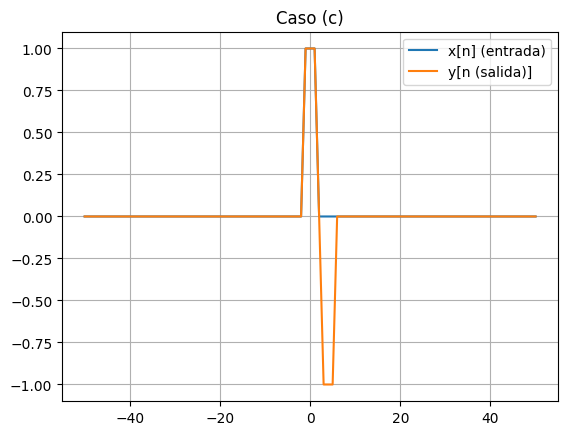

In [128]:
x_c = ((n >= -1) & (n < 2)).astype(float)
y_c = sig.convolve(x_c, h, mode='same')

plt.figure()
plt.title("Caso (c)")
plt.plot(n, x_c, label="x[n] (entrada)")
plt.plot(n, y_c, label="y[n (salida)]")
plt.legend()
plt.grid()

plt.show()

### Observaciones

### Autoevaluación del aprendisaje

En este trabajo reforze los conceptos de como modificar los parametros de mi funcion senoidal, asi que como apredí a como modularla a traves de otra senoidal y saturarla. Por otro lado, aprendí a como implementar una señal cuadrado, como asi tambien un pulso rectangular. Por ultimo, reforze mis conocimientos vistos en clase de como implementar la convolución. 
    